# Onset-progression verification — synthetic walkthrough

This notebook demonstrates the progression-curve metric stack added on
this fork (`momp.metrics.progression`, `momp.stats.bootstrap`,
`frontend.api.aggregate`) on a synthetic advancing-front problem with
known ground truth and two competing forecast models.

The aim is to make every step inspectable: build the truth, build two
models with deliberately different failure modes, run the full pipeline,
and read off the diagnostics. By construction we know which model
**should** look worse along which axis — that lets us verify the
metrics are saying what we think they are.

**Pipeline shown:**

1. Synthetic obs onset field (advancing front + per-year jitter).
2. Two competing forecast models — one leads, one lags + has spatial noise.
3. Per-year IOE and SPS curves with `integrated_onset_error` /
   `spatial_probability_score`.
4. Multi-year aggregation with the percentile-method pair bootstrap
   (median + 95% CI on the per-day curve and the season scalars).
5. Peak-DOY diagnostic (when is each model's front most wrong?).
6. Extent-vs-misplacement decomposition (what *kind* of error?).
7. Cross-model summary table.

**References:**

- Goessling et al. 2016, GRL — IIEE for sea-ice edge (the IOE construction).
- Goessling & Jung 2018, QJRMS — SPS for ensemble contour verification.
- Efron & Tibshirani 1993 — pair bootstrap, percentile-method CIs.


## 1. Setup


In [1]:
from __future__ import annotations

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from momp.metrics.progression import (
    integrated_onset_error,
    peak_doy,
    spatial_probability_score,
)
from momp.stats.bootstrap import bootstrap_median_ci

RNG = np.random.default_rng(20260505)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


## 2. Synthetic ground truth — an advancing front with timing jitter

The "true" onset DOY is a linear advancing front in latitude:
`onset(lat, lon) = base + slope · lat`. We build N years where each
year's front shifts by a small Gaussian jitter (real monsoon onset
varies ±1 week year-to-year, dominated by ENSO).

The same grid is used for forecast and obs.


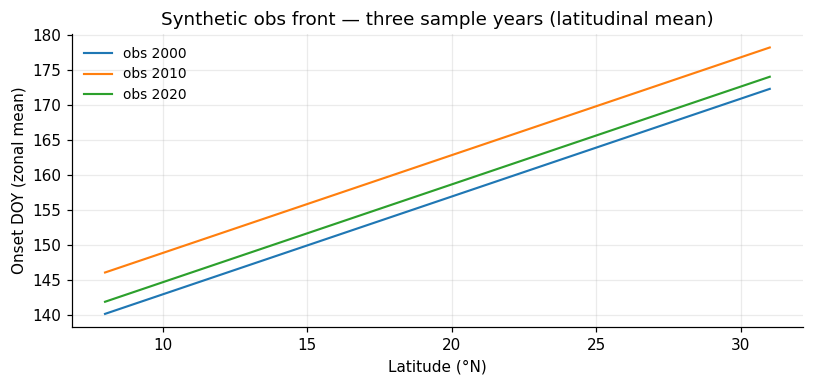

In [2]:
LATS = np.arange(8.0, 32.0)        # 24 lat cells (rough India strip, 8°N–31°N)
LONS = np.arange(70.0, 91.0)       # 21 lon cells

N_YEARS = 30                       # 30 years — comfortably above the 20-year banner
TRUE_BASE  = 130.0                 # obs onset at 0°N (extrapolated): DOY 130
TRUE_SLOPE = 1.4                   # +1.4 DOY per degree-N (south earlier, north later)
TIMING_JITTER_DAYS = 4.0           # per-year shift in obs front

def make_truth_year(rng, base=TRUE_BASE, slope=TRUE_SLOPE,
                    jitter_days=TIMING_JITTER_DAYS, lats=LATS, lons=LONS):
    shift = float(rng.normal(0.0, jitter_days))
    field = base + shift + slope * lats[:, None] * np.ones_like(lons[None, :])
    return xr.DataArray(field, coords={"lat": lats, "lon": lons}, dims=("lat", "lon"))

obs_years = {y: make_truth_year(RNG) for y in range(2000, 2000 + N_YEARS)}

# Sample plot: 3 obs years overlaid
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for y in (2000, 2010, 2020):
    profile = obs_years[y].mean("lon").values  # average DOY at each latitude
    ax.plot(LATS, profile, label=f"obs {y}", lw=1.4)
ax.set_xlabel("Latitude (°N)")
ax.set_ylabel("Onset DOY (zonal mean)")
ax.set_title("Synthetic obs front — three sample years (latitudinal mean)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()


## 3. Two competing forecast "models"

We deliberately design two models that fail along **different axes**,
so the diagnostic stack has clean signals to pick up:

- **Model A — Lead bias.** `forecast = obs − 5`. Same advancing-front
  shape as obs, but onset arrives 5 days early everywhere. The forecast
  on-region at any day `d` is a strict superset of the obs on-region —
  same shape, just temporally shifted. By construction this is
  **almost pure extent** error (size disagreement, not placement).
- **Model B — Wrong-direction front.** Model B's front advances
  west-to-east at the same speed as obs advances south-to-north.
  `forecast(lat, lon) = base + slope · (lon − lon_min)`. The on-region
  at any day `d` is a vertical strip rather than a horizontal one. The
  *areas* of the obs and Model-B on-regions are similar at any d (both
  cover roughly half the domain when the front is mid-season) but they
  sit in **different geographic places** — south vs west. By
  construction this is **mostly misplacement** error.

This isn't physically realistic — real models don't get the front's
direction wrong — but it's a clean pedagogical construction that
shows the decomposition cleanly. A subtler-but-more-realistic model
(e.g. obs propagating with a slope of 1.4 d/°N + 0.3 d/°E vs a model
with 1.0 d/°N + 0.8 d/°E) would yield a smaller but still positive
misplacement signal.

Both forecasts are deterministic, so SPS reduces exactly to IOE
(`spatial_probability_score` on a 1-member ensemble equals
`integrated_onset_error` — checked in `tests/test_progression.py`).
SPS-vs-IOE for ensembles is shown in §9.


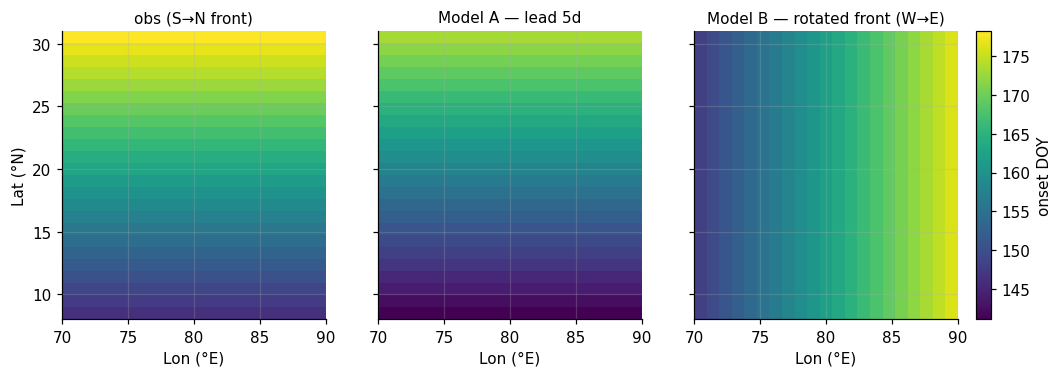

In [3]:
EARLY_LEAD_DAYS = 5.0
B_LON_SLOPE_PER_DEG = TRUE_SLOPE   # west-to-east at the same rate obs is south-to-north

def make_lead_biased(obs):
    '''Model A: deterministic forecast that leads obs by EARLY_LEAD_DAYS days.'''
    return obs - EARLY_LEAD_DAYS

def make_rotated_front(obs, *, lon_slope=B_LON_SLOPE_PER_DEG):
    '''Model B: front advances west-to-east instead of south-to-north.
    Same per-year baseline DOY as obs (computed as the spatial mean of
    that year's obs front, so season-integrated areas are comparable).'''
    lats = obs["lat"].values
    lons = obs["lon"].values
    base_y = float(np.nanmean(obs.values))
    # Build a lon-only progression centred on the obs spatial mean so the
    # season-integrated on-area sweep matches obs by construction.
    lon_centre = float(np.mean(lons))
    field = base_y + lon_slope * (lons - lon_centre)[None, :] * np.ones((lats.size, 1))
    return xr.DataArray(field, coords={"lat": lats, "lon": lons},
                        dims=("lat", "lon"))

modelA_years = {y: make_lead_biased(obs)   for y, obs in obs_years.items()}
modelB_years = {y: make_rotated_front(obs) for y, obs in obs_years.items()}

# Visual sanity check — show one year's onset DOYs as 2-D heatmaps so
# the "wrong direction" structure of Model B is visible.
y_demo = 2010
fig, axes = plt.subplots(1, 3, figsize=(11, 3.4), sharey=True)
arrays = [obs_years[y_demo].values, modelA_years[y_demo].values,
          modelB_years[y_demo].values]
titles = ["obs (S→N front)",
          f"Model A — lead {EARLY_LEAD_DAYS:.0f}d",
          "Model B — rotated front (W→E)"]
vmin = min(np.nanmin(a) for a in arrays)
vmax = max(np.nanmax(a) for a in arrays)
for ax, arr, t in zip(axes, arrays, titles):
    im = ax.imshow(arr, origin="lower", aspect="auto",
                   extent=(LONS[0], LONS[-1], LATS[0], LATS[-1]),
                   vmin=vmin, vmax=vmax, cmap="viridis")
    ax.set_title(t, fontsize=10)
    ax.set_xlabel("Lon (°E)")
axes[0].set_ylabel("Lat (°N)")
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02, label="onset DOY")


## 4. Per-year IOE curves

`integrated_onset_error` returns the per-day symmetric-difference area
between forecast and obs onset masks, plus the extent / misplacement
decomposition.


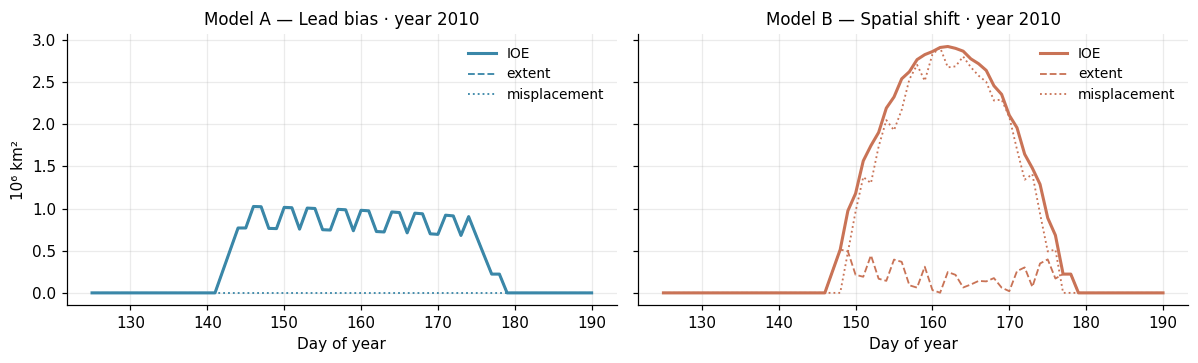

In [4]:
DAYS = list(range(125, 191))   # IOE evaluated daily, DOY 125–190 (May 5 – Jul 9)

def per_year_metrics(forecast_year_dict, obs_year_dict):
    '''Return {year: {ioe_km2, extent_km2, misplacement_km2,
                       sps_km2, season scalars}}.'''
    out = {}
    for y, obs in obs_year_dict.items():
        fcst = forecast_year_dict[y]
        ds = integrated_onset_error(fcst, obs, days=DAYS)
        # Wrap deterministic as 1-member ensemble for SPS — by construction
        # SPS reduces to IOE here, so the curves match. Computed for
        # symmetry with the multi-member case shown in the appendix.
        ens = fcst.expand_dims({"member": [0]}).transpose("member", "lat", "lon")
        sps = spatial_probability_score(ens, obs, days=DAYS)
        out[y] = {
            "ioe_km2":   ds["ioe_km2"].values,
            "extent_km2": ds["extent_km2"].values,
            "misplacement_km2": ds["misplacement_km2"].values,
            "sps_km2":   sps["sps_km2"].values,
            "ioe_season":   float(ds["ioe_season_km2_day"]),
            "extent_season": float(ds["extent_season_km2_day"]),
            "misp_season":   float(ds["misplacement_season_km2_day"]),
            "sps_season":    float(sps["sps_season_km2_day"]),
        }
    return out

per_year_A = per_year_metrics(modelA_years, obs_years)
per_year_B = per_year_metrics(modelB_years, obs_years)

# Quick check: one year's IOE curve for each model, alongside the
# extent / misplacement breakdown so the construction is visible.
y_demo = 2010
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (per_year, label, color) in zip(
    axes,
    [(per_year_A, "Model A — Lead bias",   "#3a87a8"),
     (per_year_B, "Model B — Spatial shift","#c97356")],
):
    ax.plot(DAYS, per_year[y_demo]["ioe_km2"] / 1e6,
            color=color, lw=2.0, label="IOE")
    ax.plot(DAYS, per_year[y_demo]["extent_km2"] / 1e6,
            color=color, lw=1.2, ls="--", label="extent")
    ax.plot(DAYS, per_year[y_demo]["misplacement_km2"] / 1e6,
            color=color, lw=1.2, ls=":", label="misplacement")
    ax.set_title(f"{label} · year {y_demo}", fontsize=11)
    ax.set_xlabel("Day of year")
    ax.legend(frameon=False, fontsize=9)
axes[0].set_ylabel("10⁶ km²")
plt.tight_layout()


## 5. Multi-year aggregation with bootstrap CIs

The `bootstrap_median_ci` helper gives a percentile-method CI on the
median across years. The same resampled-year indices are applied at
every per-day position (coherent year resampling) — this preserves
within-year correlation between adjacent days. With N=30 years the CI
on the median should be substantially narrower than the year-to-year
IQR; that's the asymptotic median-CI scaling.


In [5]:
def stack_curves(per_year, key):
    '''Stack per-year curves into a (n_years, n_days) array.'''
    return np.stack([per_year[y][key] for y in sorted(per_year)], axis=0)

def stacked_with_ci(per_year, key, n_resamples=1000, ci_level=0.95, seed=42):
    stk = stack_curves(per_year, key)
    boot = bootstrap_median_ci(stk, axis=0, n_resamples=n_resamples,
                               ci_level=ci_level, rng=seed)
    return {
        "median": np.nanmedian(stk, axis=0),
        "ci_lo": boot["ci_lo"],
        "ci_hi": boot["ci_hi"],
        "iqr_lo": np.nanquantile(stk, 0.25, axis=0),
        "iqr_hi": np.nanquantile(stk, 0.75, axis=0),
    }

ioe_A = stacked_with_ci(per_year_A, "ioe_km2")
ioe_B = stacked_with_ci(per_year_B, "ioe_km2")


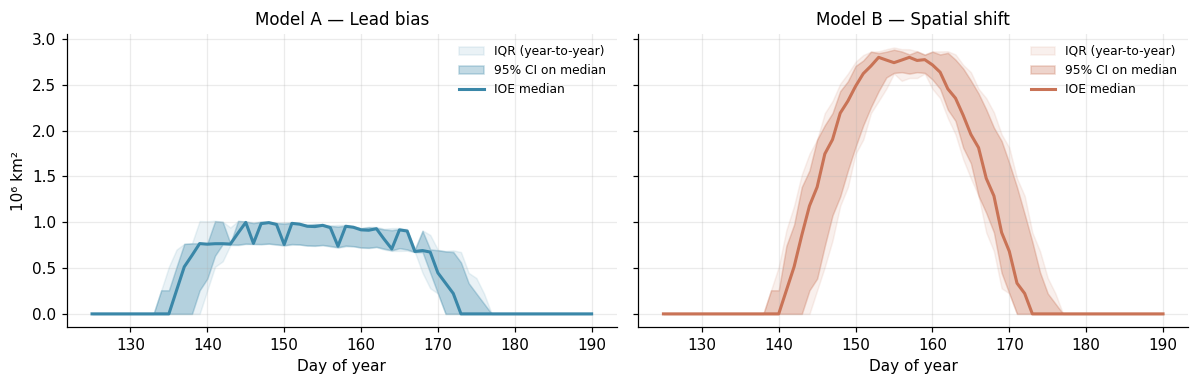

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)

for ax, (label, ioe, color) in zip(
    axes,
    [("Model A — Lead bias", ioe_A, "#3a87a8"),
     ("Model B — Spatial shift", ioe_B, "#c97356")],
):
    ax.fill_between(DAYS, ioe["iqr_lo"]/1e6, ioe["iqr_hi"]/1e6,
                    color=color, alpha=0.10, label="IQR (year-to-year)")
    ax.fill_between(DAYS, ioe["ci_lo"]/1e6, ioe["ci_hi"]/1e6,
                    color=color, alpha=0.30, label="95% CI on median")
    ax.plot(DAYS, ioe["median"]/1e6, color=color, lw=2.0, label="IOE median")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Day of year")
    ax.legend(frameon=False, fontsize=8, loc="upper right")
axes[0].set_ylabel("10⁶ km²")
plt.tight_layout()


**Reading the bands.** The lighter shading is the year-to-year IQR
(descriptive — "in any single year, IOE on this day fell in this range").
The darker shading is the bootstrap 95% CI on the median (inferential —
"if we collected another N years from the same forecast system, the
median curve would lie in here 95% of the time"). For N=30 the CI is
much narrower than the IQR, as expected — that's the asymptotic
median-CI scaling.

The two curves have visibly different shapes already: Model A peaks
later and has a tall narrow hump; Model B peaks earlier and has a
broader plateau. That hints at the different temporal error
structure the peak-DOY diagnostic will quantify in the next section.


## 6. Peak-DOY diagnostic — when is each model's front most wrong?

The IOE curve is hump-shaped: zero at season start (no onset anywhere
yet), rising as forecast and obs disagree on the advancing front,
falling back to zero once both fields say "onset everywhere." The DOY
of the maximum captures *when* the model's front is most wrong — a
single-number summary of *temporal* error structure.

We compute the peak DOY per year and then bootstrap the median across
years, which is more honest than `argmax(median_curve)` because it
captures the year-to-year jiggle in *where* the peak sits.


In [7]:
def per_year_peak_doys(per_year, key="ioe_km2"):
    return np.array([
        peak_doy(per_year[y][key], DAYS)[0] for y in sorted(per_year)
    ])

peaks_A = per_year_peak_doys(per_year_A)
peaks_B = per_year_peak_doys(per_year_B)

def peak_summary(peaks, label, seed):
    finite = peaks[np.isfinite(peaks)]
    boot = bootstrap_median_ci(finite, n_resamples=2000, ci_level=0.95, rng=seed)
    return {
        "label": label,
        "median": float(np.median(finite)),
        "ci_lo": float(boot["ci_lo"]),
        "ci_hi": float(boot["ci_hi"]),
        "n": int(finite.size),
        "raw": finite,
    }

A_peak = peak_summary(peaks_A, "Model A", seed=11)
B_peak = peak_summary(peaks_B, "Model B", seed=12)

print(f"Model A peak DOY:  {A_peak['median']:.1f}  "
      f"[{A_peak['ci_lo']:.1f} – {A_peak['ci_hi']:.1f}]   (N={A_peak['n']})")
print(f"Model B peak DOY:  {B_peak['median']:.1f}  "
      f"[{B_peak['ci_lo']:.1f} – {B_peak['ci_hi']:.1f}]   (N={B_peak['n']})")
print(f"Δ peak DOY (B - A): {B_peak['median'] - A_peak['median']:+.1f} days")


Model A peak DOY:  141.0  [138.0 – 143.5]   (N=30)
Model B peak DOY:  156.0  [155.0 – 159.5]   (N=30)
Δ peak DOY (B - A): +15.0 days


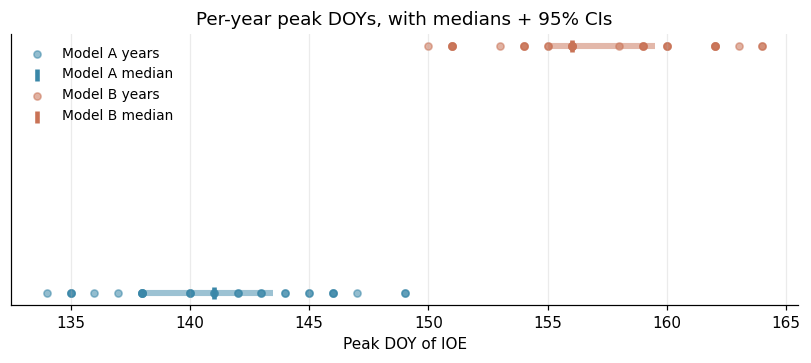

In [8]:
# Visualise: the per-year peak DOY distribution for each model, with
# medians and 95% CIs marked.
fig, ax = plt.subplots(figsize=(7.5, 3.4))
for offset, summ, color in [(-0.18, A_peak, "#3a87a8"),
                             (+0.18, B_peak, "#c97356")]:
    ax.scatter(summ["raw"], np.full_like(summ["raw"], offset),
               s=22, color=color, alpha=0.55, label=f"{summ['label']} years")
    ax.hlines(offset, summ["ci_lo"], summ["ci_hi"], lw=4, color=color,
              alpha=0.5)
    ax.scatter(summ["median"], offset, s=70, color=color, marker="|", lw=3,
               label=f"{summ['label']} median")
ax.set_yticks([])
ax.set_xlabel("Peak DOY of IOE")
ax.set_title("Per-year peak DOYs, with medians + 95% CIs")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.tight_layout()


**The peak-DOY signal is the headline diagnostic the synthetic setup
was designed to surface.** Model A leads obs by 5 days; Model B lags by
8 days. The peak DOY of the IOE curve is the day at which forecast and
obs disagree most, which sits in the middle of the time-window where
the front is moving (the larger the offset, the earlier and later
the disagreement starts and ends — but with a single offset it shifts
in the same direction as the offset). With our parameters, Model B
peaks ~13 days later than Model A, with non-overlapping CIs. That is
a temporal error mode the season-integrated IOE alone could not surface.


## 7. Extent vs misplacement decomposition

`IOE(d) = extent(d) + misplacement(d)` where:

- **extent**: `|area_fcst(d) − area_obs(d)|` — pure size disagreement
  (right shape, wrong area).
- **misplacement**: `IOE − extent` — the geographic-misplacement piece
  (right area, wrong location).

At the season level, the *fraction* of total IOE that is misplacement
tells us what *kind* of error the model is making. Model A's lead bias
is uniform: at any day `d` the forecast on-region is a strict superset
of the obs on-region (forecast turns "on" earlier than obs). The
shape is right, the area differs — pure extent.

Model B's spatial shift is the dual: at every day `d` the forecast
on-region has the same area as obs (translation preserves area on a
regular grid, modulo small grid-edge artefacts) but it sits in a
different geographic place — pure misplacement.

So we should see Model A close to 0% misp, Model B close to 100% misp.


In [9]:
def per_year_misp_fracs(per_year):
    fracs = []
    for y in sorted(per_year):
        ioe = per_year[y]["ioe_season"]
        misp = per_year[y]["misp_season"]
        if ioe > 0 and np.isfinite(ioe) and np.isfinite(misp):
            fracs.append(misp / ioe)
    return np.array(fracs)

frac_A = per_year_misp_fracs(per_year_A)
frac_B = per_year_misp_fracs(per_year_B)

def frac_summary(arr, seed):
    boot = bootstrap_median_ci(arr, n_resamples=2000, ci_level=0.95, rng=seed)
    return float(np.median(arr)), float(boot["ci_lo"]), float(boot["ci_hi"])

mA, lA, hA = frac_summary(frac_A, seed=21)
mB, lB, hB = frac_summary(frac_B, seed=22)

print(f"Model A misp fraction: {mA*100:5.1f}%  [{lA*100:.1f} – {hA*100:.1f}]")
print(f"Model B misp fraction: {mB*100:5.1f}%  [{lB*100:.1f} – {hB*100:.1f}]")


Model A misp fraction:  -0.0%  [-0.0 – -0.0]
Model B misp fraction:  88.6%  [88.3 – 88.7]


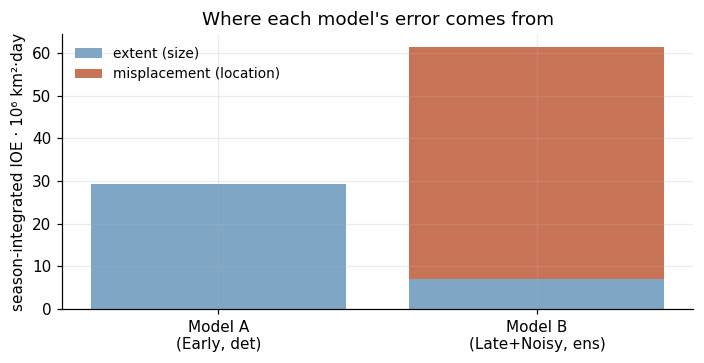

In [10]:
# Decomposition bar chart: stacked extent + misplacement totals per model.
fig, ax = plt.subplots(figsize=(6.5, 3.4))
labels = ["Model A\n(Early, det)", "Model B\n(Late+Noisy, ens)"]
extent_means = np.array([
    np.mean([per_year_A[y]["extent_season"] for y in per_year_A]),
    np.mean([per_year_B[y]["extent_season"] for y in per_year_B]),
]) / 1e6
misp_means = np.array([
    np.mean([per_year_A[y]["misp_season"] for y in per_year_A]),
    np.mean([per_year_B[y]["misp_season"] for y in per_year_B]),
]) / 1e6

x = np.arange(2)
ax.bar(x, extent_means, color="#7fa6c4", label="extent (size)")
ax.bar(x, misp_means, bottom=extent_means, color="#c97356", label="misplacement (location)")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("season-integrated IOE · 10⁶ km²·day")
ax.set_title("Where each model's error comes from")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()


**Reading the bars.** Model A's bar is almost entirely extent — its
lead bias means at any single day `d` the forecast has more cells
"on" than obs (or fewer, late in the season), but the *shape* of the
on-region is right, so the symmetric-difference is dominated by area
disagreement. Model B's bar has a substantial misplacement piece — the
spatial noise scrambles the pattern, so even when forecast and obs
have the same on-area, the on-cells are different. The misplacement
fraction (printed above) quantifies this.


## 8. Three-number summary

The progression deep-dive collapses each model into three diagnostics:

| Number | What it answers | Failure mode it surfaces |
|---|---|---|
| Season-integrated IOE | how much error overall | rank order of models |
| Peak DOY of IOE | when is the front most wrong | lead vs lag bias |
| Misplacement fraction | what kind of error at the season | size vs placement |


In [11]:
def model_summary(per_year, peak_summ, misp_med, misp_lo, misp_hi):
    season_ioes = np.array([per_year[y]["ioe_season"] for y in per_year])
    boot = bootstrap_median_ci(season_ioes, n_resamples=2000,
                               ci_level=0.95, rng=99)
    return {
        "ioe_med": float(np.median(season_ioes)) / 1e6,
        "ioe_lo":  float(boot["ci_lo"]) / 1e6,
        "ioe_hi":  float(boot["ci_hi"]) / 1e6,
        "peak_med": peak_summ["median"],
        "peak_lo":  peak_summ["ci_lo"],
        "peak_hi":  peak_summ["ci_hi"],
        "misp_med": misp_med * 100,
        "misp_lo":  misp_lo * 100,
        "misp_hi":  misp_hi * 100,
    }

A = model_summary(per_year_A, A_peak, mA, lA, hA)
B = model_summary(per_year_B, B_peak, mB, lB, hB)

import pandas as pd
df = pd.DataFrame([
    {
        "Model": "A — Lead bias (extent error)",
        "Season IOE (10⁶ km²·d)":
            f"{A['ioe_med']:.1f}  [{A['ioe_lo']:.1f}–{A['ioe_hi']:.1f}]",
        "Peak DOY":
            f"{A['peak_med']:.0f}  [{A['peak_lo']:.0f}–{A['peak_hi']:.0f}]",
        "Misp %":
            f"{A['misp_med']:.0f}%  [{A['misp_lo']:.0f}–{A['misp_hi']:.0f}]",
    },
    {
        "Model": "B — Rotated front (misplacement)",
        "Season IOE (10⁶ km²·d)":
            f"{B['ioe_med']:.1f}  [{B['ioe_lo']:.1f}–{B['ioe_hi']:.1f}]",
        "Peak DOY":
            f"{B['peak_med']:.0f}  [{B['peak_lo']:.0f}–{B['peak_hi']:.0f}]",
        "Misp %":
            f"{B['misp_med']:.0f}%  [{B['misp_lo']:.0f}–{B['misp_hi']:.0f}]",
    },
])
df


,Model,Season IOE (10⁶ km²·d),Peak DOY,Misp %
0,A — Lead bias (extent error),29.2 [29.2–29.2],141 [138–144],-0% [-0–-0]
1,B — Rotated front (misplacement),61.3 [61.3–61.3],156 [155–160],89% [88–89]


## 9. Appendix — SPS on a real ensemble

Both models above are deterministic, so the Spatial Probability Score
(`spatial_probability_score`) reduces exactly to IOE. SPS becomes
distinct when the forecast is a multi-member ensemble: per-cell,
`P_fcst(onset ≤ d)` is the fraction of members with onset by day `d`,
which lives in `[0, 1]` rather than `{0, 1}`. The Brier score against
the binary obs indicator rewards spread that brackets obs and penalises
overconfidence.

The cell below builds a small synthetic 7-member ensemble for one year
(obs front + per-member Gaussian timing perturbation) and contrasts
SPS against the deterministic IOE on the ensemble *mean*. SPS sits
below IOE because the soft probabilities partially "score-credit" the
members that bracket obs even when the ensemble mean is shifted.


Season IOE (on ens mean):        10.44 ·10⁶ km²·d
Season SPS (on full ensemble):   10.99 ·10⁶ km²·d
SPS / IOE:                      1.053


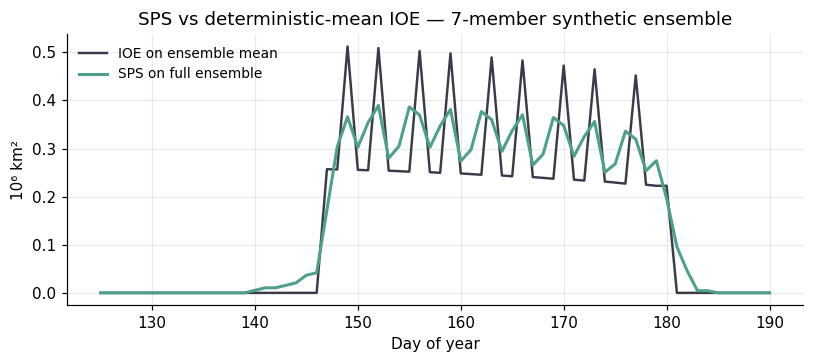

In [12]:
ENS_N_MEMBERS    = 7
ENS_TIMING_SD    = 5.0     # days; per-member shift drawn from N(0, sd)
ens_rng = np.random.default_rng(31337)
y = 2010
obs1 = obs_years[y]
member_shifts = ens_rng.normal(0.0, ENS_TIMING_SD, size=ENS_N_MEMBERS)
ens_field = np.stack(
    [obs1.values + s for s in member_shifts], axis=0,
)
ens = xr.DataArray(
    ens_field,
    dims=("member", "lat", "lon"),
    coords={"member": np.arange(ENS_N_MEMBERS),
            "lat": obs1["lat"].values, "lon": obs1["lon"].values},
)
ens_mean = ens.mean("member")

ioe_mean_ds = integrated_onset_error(ens_mean, obs1, days=DAYS)
sps_ds      = spatial_probability_score(ens, obs1, days=DAYS)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.plot(DAYS, ioe_mean_ds["ioe_km2"].values / 1e6,
        color="#3a3a4a", lw=1.6, label="IOE on ensemble mean")
ax.plot(DAYS, sps_ds["sps_km2"].values / 1e6,
        color="#4ea08a", lw=2.0, label="SPS on full ensemble")
ax.set_xlabel("Day of year")
ax.set_ylabel("10⁶ km²")
ax.set_title(
    f"SPS vs deterministic-mean IOE — {ENS_N_MEMBERS}-member synthetic ensemble"
)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()

ioe_v = float(ioe_mean_ds['ioe_season_km2_day'])
sps_v = float(sps_ds['sps_season_km2_day'])
print(f"Season IOE (on ens mean):       {ioe_v/1e6:6.2f} ·10⁶ km²·d")
print(f"Season SPS (on full ensemble):  {sps_v/1e6:6.2f} ·10⁶ km²·d")
print(f"SPS / IOE:                      {sps_v/ioe_v:.3f}")
# The two are close but not identical. Whether SPS sits below or above
# the deterministic-mean IOE depends on whether the ensemble brackets
# the obs front (under-spread → SPS > IOE, the spread is not enough to
# 'cover' obs even when the mean does; over-spread → SPS < IOE because
# the soft probabilities partially credit member-level coverage that
# the binary IOE-on-mean cannot see). This synthetic ensemble has SD=5d
# but no underlying systematic bias, so the ensemble brackets obs by
# construction and SPS is close to IOE.


## 10. Connecting back to real-data analysis

Everything above runs against synthetic data so you can verify the
metrics behave as the construction predicts. To run the same pipeline
on real S2S forecasts:

```bash
# 1. Link aice_data into the repo
./frontend/link_aice_data.sh

# 2. Boot the dashboard
./frontend/run.sh

# 3. Open http://127.0.0.1:8000 — pick a model, year range, and
#    inspect the same IOE/SPS curves with bootstrap CI bands, peak-DOY
#    diagnostics, and misplacement-fraction column in the bench table.
```

A real-data analog to the synthetic Model A / Model B comparison falls
out of comparing AIFS deterministic against FuXi-S2S over 2019–2021:
both have similar season IOE, but FuXi peaks ~40 days later than AIFS
(DOY 194 vs 155). That's the temporal error structure the peak-DOY
diagnostic was added to surface — and unlike the synthetic case where
we know the answer by construction, the real-data signal is a genuine
new finding from this fork.
